# Verify dataset classes and data loader

In [1]:
from pathlib import Path
import sys
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.datasets.sb_dataset import SB_Dataset
from src.datasets.sb_dataset_inc_negatives import SB_Dataset_Inc_Negatives
from src.datasets.load_dataset import load_dataset

In [2]:
# Load rotated images through the existing Dataset class
with open('/home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/config/oct_sb_faster_rcnn.yaml') as f:
    config = yaml.load(f, yaml.FullLoader)
    
(train_loader, val_loader, test_loader), (train_dataset, val_dataset, test_dataset) = load_dataset(config)


train set: 8410 examples
val set: 1402 examples
test set: 1111 examples


/home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/.venv/lib/python3.11/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
/home/qzhang-server1/Documents/Georgia/oct-side-branch-detection/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  0%|          | 0/5 [00:00<?, ?it/s]

torch.Size([0, 4])
0006_BERN-002-RCA_DIST_BL_0106


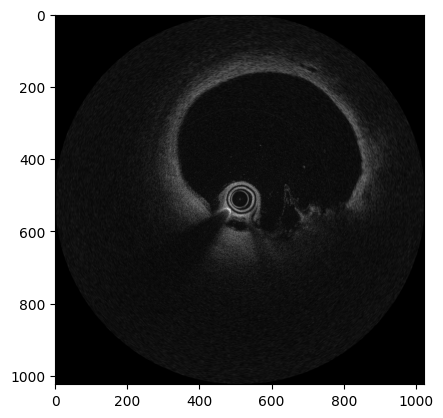

 20%|██        | 1/5 [00:00<00:02,  1.42it/s]

torch.Size([0, 4])
0445_BERN-117-LCX_FU_0201


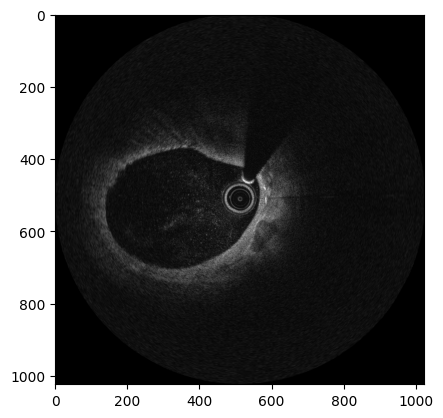

 40%|████      | 2/5 [00:01<00:02,  1.28it/s]

torch.Size([0, 4])
0171_BERN-045-RCA_FU_0179


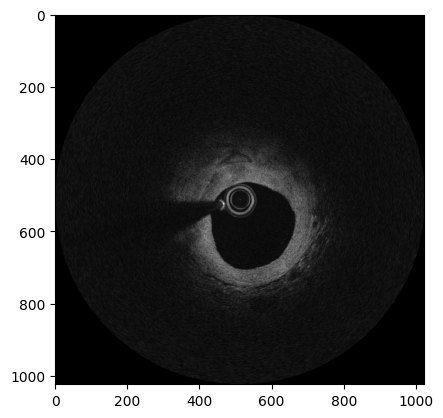

 60%|██████    | 3/5 [00:02<00:01,  1.36it/s]

torch.Size([0, 4])
0085_BERN-023-RCA_FU_0179


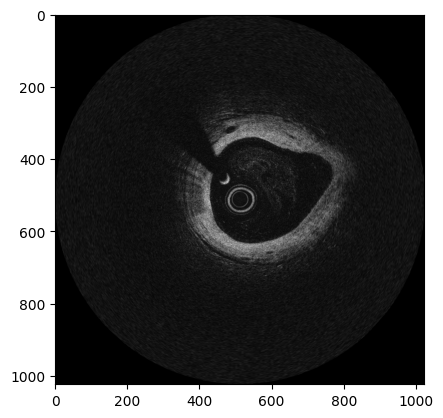

 80%|████████  | 4/5 [00:02<00:00,  1.35it/s]

torch.Size([1, 4])
0611_BERN-160-LCX_FU_0169


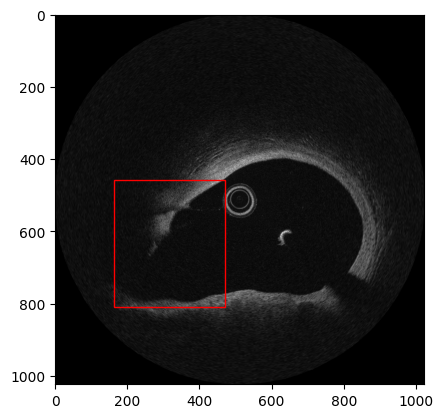

100%|██████████| 5/5 [00:03<00:00,  1.32it/s]


In [4]:
for i in tqdm(range(5)):
    image, target = next(iter(train_loader))
    
    #print(target)
    
    bboxes = target[0]['boxes']
    # print(bboxes)
    # print(image[0].shape, image[0].max())
    
    print(bboxes.shape)
    
    
    #print(bbox)
    print(target[0]["image_id"])
    
    f, ax = plt.subplots()
    ax.imshow(image[0][0].numpy(), cmap='gray')
    for bbox in bboxes:
        #bbox = [b*(224/1024) for b in bbox]
        x, y, width, height  = bbox[0], bbox[1], bbox[2]-bbox[0], bbox[3]-bbox[1]
        rect = patches.Rectangle((x, y),width, height, linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
    plt.show()
    
    #print(len(image), image[0].shape)
    #break